In [1]:
import haccytrees.mergertrees
import h5py
import math
import numpy as np
import numpy.fft as fft 
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from itertools import groupby
from matplotlib.ticker import ScalarFormatter
%load_ext line_profiler
%reload_ext autoreload
%autoreload 1
%aimport help_func_haccytrees

pyfftw not available, using numpy fft


In [21]:
%%time
# For full version: '/data/a/cpac/mbuehlmann/LastJourney/forest/m000p.forest.000.hdf5' with 'LastJourney'
forest, progenitor_array = haccytrees.mergertrees.read_forest('/data/a/cpac/mbuehlmann/LastJourney/forest/m000p.forest.000.hdf5',
                                                              'LastJourney', nchunks=1, chunknum=0, mass_threshold = 2.7*10**11, include_fields = ["tree_node_mass", "snapnum", "fof_halo_tag", "sod_halo_cdelta", "fof_halo_center_x", "fof_halo_center_y", "fof_halo_center_z"])
# For smaller version: '/data/a/cpac/mbuehlmann/LJSV/forest/m000p.forest.hdf5' with 'LastJourneySV' 
#forest, progenitor_array = haccytrees.mergertrees.read_forest('/data/a/cpac/mbuehlmann/LJSV/forest/m000p.forest.hdf5',
#                                                              'LastJourneySV', nchunks=1, chunknum=0, mass_threshold = 2.7*10**11, include_fields = ["tree_node_mass", "snapnum", "fof_halo_tag", "sod_halo_cdelta", "fof_halo_center_x", "fof_halo_center_y", "fof_halo_center_z"])

CPU times: user 8.82 s, sys: 11 s, total: 19.9 s
Wall time: 19.8 s


In [22]:
thresholds = [5*10**11]
thresholds_are_absolute = True
norm = np.int(2.7*10**9)
xaxis = 'z_nums'
norm_tf = True
avg_tf = True
# Convert snapshots to redshifts -- opposite order (chronological)
redshifts = np.flip(np.array([10.044, 9.8065, 9.5789, 9.3608, 9.1515, 8.7573, 8.5714, 8.3925, 8.0541, 7.8938, 7.7391, 7.4454, 7.3058, 7.04, 6.9134, 6.6718, 6.5564, 6.3358, 6.1277, 6.028, 5.8367, 5.6556, 5.4839, 5.3208, 5.2422, 5.0909, 4.9467, 4.7429, 4.6145, 4.4918, 4.3743, 4.2618, 4.1015, 4.00, 3.8551, 3.763, 3.6313, 3.5475, 3.4273, 3.3133, 3.205, 3.102, 3.0361, 2.9412, 2.8506, 2.7361, 2.6545, 2.5765, 2.4775, 2.4068, 2.3168, 2.2524, 2.1703, 2.0923, 2.018, 1.9472, 1.8797, 1.7994, 1.7384, 1.68, 1.6104, 1.5443, 1.4938, 1.4334, 1.3759, 1.321, 1.2584, 1.2088, 1.152, 1.1069, 1.0552, 1.006, 0.9591, 0.9143, 0.8646, 0.824, 0.7788, 0.7358, 0.6948, 0.6557, 0.6184, 0.5777, 0.5391, 0.5022, 0.4714, 0.4337, 0.4017, 0.3636, 0.3347, 0.3035, 0.2705, 0.2423, 0.2123, 0.1837, 0.1538, 0.1279, 0.1008, 0.0749, 0.0502, 0.0245, 0.00]))
N = 256
L = 250

# Fossil Groups Candidates

In [31]:
%%time
mbins = [1e13, 1e14]
xaxis = 'snap_nums'
absolute_threshold = True
threshold = 5e11
z_thresh = 1
norm_tf = False
# Go find yourself some fossil groups!
target_idx = help_func_haccytrees.bin_halos(forest, mbins)
binned_mainbranch_index, binned_mainbranch_masses = help_func_haccytrees.get_binned_branches(target_idx, forest, normalized = norm_tf)
binned_mainbranch_mergers = help_func_haccytrees.get_binned_mainbranch_mergers(forest, progenitor_array, binned_mainbranch_index, absolute_threshold)
binned_major_mergers = help_func_haccytrees.get_binned_major_mergers(binned_mainbranch_mergers, threshold)
binned_lmm_redshifts, binned_lmm_index = help_func_haccytrees.get_binned_lmms(binned_major_mergers, threshold)
binned_fgs, binned_failed, binned_violent_idx = help_func_haccytrees.find_binned_specials(forest, binned_mainbranch_index, binned_major_mergers, binned_lmm_redshifts, target_idx, z_thresh)
print(len(target_idx[0]))
print(len(binned_fgs[0]))

mainbranch_index shape:  (41428, 101)
main_merger_index shape:  (2906143,)
41428
2324
CPU times: user 535 ms, sys: 17.7 ms, total: 553 ms
Wall time: 337 ms


In [27]:
import haccytrees
import haccytrees.mergertrees
import numpy as np
import h5py


n_files = 384
# n_files = 1
base = "/eagle/LastJourney/mbuehlmann/LastJourney/forest/forest/m000p.forest"

mm_thresh = 5e11
z0_masslim = [1e13, 1e14]


# the simulation
simulation = haccytrees.Simulation.simulations["LastJourney"]
scale_factors = simulation.step2a(np.array(simulation.cosmotools_steps))
last_snap = len(simulation.cosmotools_steps) - 1

In [28]:
mlims = mbins
sn = 100
z0_mask = forest['snapnum'] == sn
target_mask = z0_mask & (forest['tree_node_mass'] > mlims[0]) * (forest['tree_node_mass'] < mlims[1])
len(target_mask[target_mask])

41428

In [29]:
mainbranch_index = haccytrees.mergertrees.get_mainbranch_indices(
    forest, simulation="LastJourney", target_index=target_idx
)
active_mask = mainbranch_index > 0 # I used != -1

# get indices to secondary progenitors (main mergers)
main_merger_index = haccytrees.mergertrees.get_nth_progenitor_indices(
    forest, progenitor_array, target_index=mainbranch_index[active_mask], n=2
)

# the index will be negative if there's no merger, mask those out
merger_mask = main_merger_index >= 0

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
No implementation of function Function(<built-in function setitem>) found for signature:
 
 >>> setitem(array(int64, 2d, C), Tuple(int64, array(int16, 1d, C)), array(int64, 1d, C))
 
There are 16 candidate implementations:
   - Of which 14 did not match due to:
   Overload of function 'setitem': File: <numerous>: Line N/A.
     With argument(s): '(array(int64, 2d, C), Tuple(int64, array(int16, 1d, C)), array(int64, 1d, C))':
    No match.
   - Of which 2 did not match due to:
   Overload in function 'SetItemBuffer.generic': File: numba/core/typing/arraydecl.py: Line 171.
     With argument(s): '(array(int64, 2d, C), Tuple(int64, array(int16, 1d, C)), array(int64, 1d, C))':
    Rejected as the implementation raised a specific error:
      NotImplementedError: only one advanced index supported
  raised from /home/acossairt/miniconda3/envs/fossil_groups_env/lib/python3.7/site-packages/numba/core/typing/arraydecl.py:65

In [123]:
fgs = binned_fgs[0]
print(len(fgs))

382


# Cosmic Web Map

In [124]:
# Get delta
with h5py.File("/data/a/cpac/mbuehlmann/LJSV/maps/density.hdf5", "r") as f:
    delta = np.array(f['delta+1'], dtype=np.float64) - 1

In [192]:
# Smooth the density field first
sigma = 2 # Mpc/h
delta_smooth = help_func_haccytrees.smooth_f(delta, sigma)

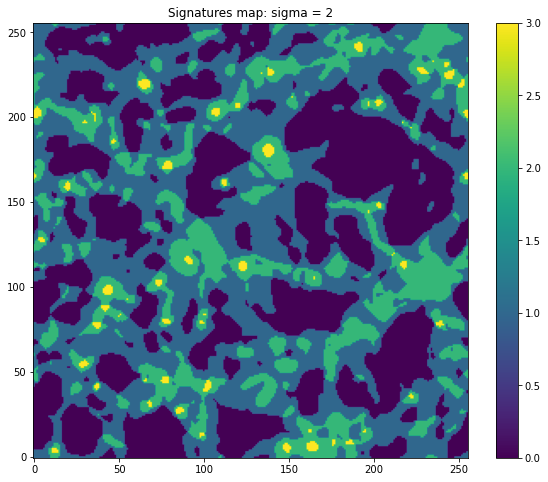

In [193]:
# Now, find signatures
signatures_are_of_smooth_field = True
if signatures_are_of_smooth_field:
    smooth_sigs = help_func_haccytrees.calculate_signatures(delta_smooth, threshold = -0.2)
else:
    smooth_sigs = help_func_haccytrees.calculate_signatures(delta, threshold = -0.2)
    
fig, ax = plt.subplots(figsize=(10, 8))
slice_n = 100
pcm = plt.imshow(smooth_sigs[:, :, slice_n].T, cmap='viridis', vmin=0, vmax=3, origin = 'lower')
fig.colorbar(pcm)

if signatures_are_of_smooth_field:
    ax.set_title("Signatures map: sigma = " + str(sigma))
    #fig.savefig("delta_sigs_smooth_sigma" + str(sigma) + ".png")
else:
    ax.set_title("Signatures map (unsmoothed field)")
    #fig.savefig("delta_sigs_unsmoothed.png")

# Find FG Candidates in Cosmic Web

In [194]:
x_coords_fg = forest['fof_halo_center_x'][fgs]*N/L # this just rounds everything down. Is that what we want?
y_coords_fg = forest['fof_halo_center_y'][fgs]*N/L # How different would it be if we rounded up?
z_coords_fg = forest['fof_halo_center_z'][fgs]*N/L
fg_sigs = smooth_sigs[x_coords_fg.astype(int), y_coords_fg.astype(int), z_coords_fg.astype(int)]
fg_sig_keys, fg_sig_counts = np.unique(fg_sigs, return_counts=True)
fg_vol_fractions = fg_sig_counts / np.sum(fg_sig_counts)
fg_errs = np.sqrt(fg_sig_counts)/np.sum(fg_sig_counts)
print(fg_sig_keys)
print(fg_sig_counts)
print(np.sqrt(fg_sig_counts))
print(fg_vol_fractions)
print(fg_errs)
for i in range(len(fg_vol_fractions)):
    print("{:.3f}".format(fg_vol_fractions[i]) + "+/-" + "{:.3f}".format(fg_errs[i]))

[2 3]
[262 120]
[16.18641406 10.95445115]
[0.68586387 0.31413613]
[0.04237281 0.02867657]
0.686+/-0.042
0.314+/-0.029


# Compare to halos in general

In [195]:
all_halos = target_idx[0]
print(len(all_halos))
x_coords_all = forest['fof_halo_center_x'][all_halos]*N/L
y_coords_all = forest['fof_halo_center_y'][all_halos]*N/L
z_coords_all = forest['fof_halo_center_z'][all_halos]*N/L
print(np.max(forest['fof_halo_center_z'][all_halos]))
print(np.max(z_coords_all))
general_sigs = smooth_sigs[x_coords_all.astype(int), y_coords_all.astype(int), z_coords_all.astype(int)]
general_sig_keys, general_sig_counts = np.unique(general_sigs, return_counts=True)
general_vol_fractions = general_sig_counts / np.sum(general_sig_counts)
general_errs = np.sqrt(general_sig_counts) / np.sum(general_sig_counts)
print(general_sig_keys)
print(general_sig_counts)
print(np.sqrt(general_sig_counts))
print(general_vol_fractions)
print(general_errs)
for i in range(len(general_vol_fractions)):
    print("{:.3f}".format(general_vol_fractions[i]) + "+/-" + "{:.3f}".format(general_errs[i]))

6197
249.99184
255.99164
[1 2 3]
[  26 3091 3080]
[ 5.09901951 55.5967625  55.4977477 ]
[0.00419558 0.49878974 0.49701468]
[0.00082282 0.00897156 0.00895558]
0.004+/-0.001
0.499+/-0.009
0.497+/-0.009


# Compare to non-FGs

In [196]:
non_fgs = all_halos[~np.isin(all_halos, fgs)]
print(len(all_halos))
print(len(non_fgs))
print(len(all_halos) - len(non_fgs))
x_coords_non_fg = forest['fof_halo_center_x'][non_fgs]*N/L # this just rounds everything down. Is that what we want?
y_coords_non_fg = forest['fof_halo_center_y'][non_fgs]*N/L # How different would it be if we rounded up?
z_coords_non_fg = forest['fof_halo_center_z'][non_fgs]*N/L
non_fg_sigs = smooth_sigs[x_coords_non_fg.astype(int), y_coords_non_fg.astype(int), z_coords_non_fg.astype(int)]
non_fg_sig_keys, non_fg_sig_counts = np.unique(non_fg_sigs, return_counts=True)
non_fg_vol_fractions = non_fg_sig_counts / np.sum(non_fg_sig_counts)
non_fg_errs = np.sqrt(non_fg_sig_counts)/np.sum(non_fg_sig_counts)
print(non_fg_sig_keys)
print(non_fg_sig_counts)
print(non_fg_vol_fractions)
print(non_fg_errs)
print(np.sqrt(non_fg_sig_counts))

6197
5815
382
[1 2 3]
[  26 2829 2960]
[0.0044712  0.48650043 0.50902837]
[0.00087687 0.00914675 0.00935613]
[ 5.09901951 53.18834459 54.40588203]


# Compare to Rugged Individualists

In [199]:
rugs = binned_failed[0]
x_coords_rugs = forest['fof_halo_center_x'][rugs]*N/L # this just rounds everything down. Is that what we want?
y_coords_rugs = forest['fof_halo_center_y'][rugs]*N/L # How different would it be if we rounded up?
z_coords_rugs = forest['fof_halo_center_z'][rugs]*N/L
rugs_sigs = smooth_sigs[x_coords_rugs.astype(int), y_coords_rugs.astype(int), z_coords_rugs.astype(int)]
rugs_sig_keys, rugs_sig_counts = np.unique(rugs_sigs, return_counts=True)
rugs_vol_fractions = rugs_sig_counts / np.sum(rugs_sig_counts)
rugs_errs = np.sqrt(rugs_sig_counts)/np.sum(rugs_sig_counts)
print(rugs_sig_keys)
print(rugs_sig_counts)
print(np.sqrt(rugs_sig_counts))
print(rugs_vol_fractions)
print(rugs_errs)

[1 2 3]
[ 1 14  8]
[1.         3.74165739 2.82842712]
[0.04347826 0.60869565 0.34782609]
[0.04347826 0.16268076 0.12297509]


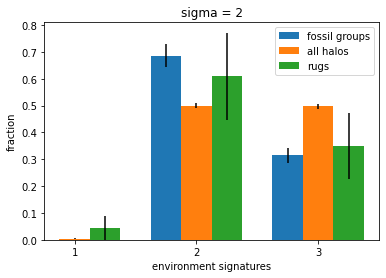

In [200]:
fig, ax = plt.subplots()
width = 0.25
ax.bar(fg_sig_keys - width, fg_vol_fractions, width, yerr = fg_errs, label = "fossil groups")
#ax.bar(non_fg_sig_keys, non_fg_vol_fractions, width, yerr = non_fg_errs, label = "non fossil groups")
ax.bar(general_sig_keys, general_vol_fractions, width, yerr = general_errs, label = "all halos")
ax.bar(rugs_sig_keys + width, rugs_vol_fractions, width, yerr = rugs_errs, label = "rugs")
ax.set_xticks(general_sig_keys)
ax.set_xlabel("environment signatures")
ax.set_ylabel("fraction")
ax.set_title("sigma = " + str(sigma))
ax.legend()
fig.savefig("halo_sigs_bar_" + str(sigma) + "_rugs.png")

# Evaluate (delta + 1)'s at halo centers

In [79]:
print(delta.shape)

(256, 256, 256)


[  3  13  51 123 220 358 470 544 605 569 540 471 397 327 253 222 207 176
 112  93  78  80  53  47  45  37  24  16  19  12   9   5   6   4   1   4
   0   2   0   1]
6197
[ 1  4  2  7 10 28 30 36 31 39 24 28 23 29 12 10 13 10 14  3  5  7  4  3
  2  3  0  1  0  1  0  0  0  1  0  1  0  0  0  0]
382


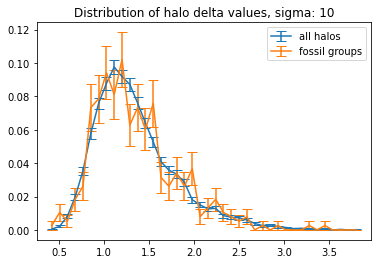

In [117]:
# Evaluate delta + 1 (smoothed) at these halo locations
plt.rc('figure', facecolor='w')
n_bins = 40
#bin_edges = np.linspace(0,10,n_bins)

smooth = True
if smooth:
    sigma = 10 # 10 Mpc/h
    delta_smooth = help_func_haccytrees.smooth_f(delta, sigma)
    fg_deltas = (delta_smooth + 1)[x_coords_fg.astype(int), y_coords_fg.astype(int), z_coords_fg.astype(int)]
    all_halos_deltas = (delta_smooth + 1)[x_coords_all.astype(int), y_coords_all.astype(int), z_coords_all.astype(int)]
    fgs = fg_deltas
    all_halos = all_halos_deltas
else:
    sigma = "none"
    no_smooth_fg_deltas = (delta + 1)[x_coords_fg.astype(int), y_coords_fg.astype(int), z_coords_fg.astype(int)]
    no_smooth_all_halos_deltas = (delta + 1)[x_coords_all.astype(int), y_coords_all.astype(int), z_coords_all.astype(int)]
    fgs = no_smooth_fg_deltas
    all_halos = no_smooth_all_halos_deltas

fig, ax = plt.subplots()
labels = ["all halos", "fossil groups"]
linestyles = ['-', '--']
h_max = np.max([np.max(all_halos), np.max(fgs)])
h_min = np.min([np.min(all_halos), np.min(fgs)])
for i, these_deltas in enumerate([all_halos, fgs]):
    hist = np.histogram(these_deltas, n_bins, (h_min, h_max))
    print(hist[0])
    #hist = np.histogram(these_deltas, n_bins)
    norm_factor = len(these_deltas)
    print(norm_factor)
    yerr = np.sqrt(hist[0])/norm_factor
    bin_centers = (hist[1][:-1] + hist[1][1:]) / 2
    ax.errorbar(bin_centers, hist[0]/norm_factor, yerr = yerr, capsize = 5, label = labels[i])
    ax.legend()

ax.set_title("Distribution of halo delta values, sigma: " + str(sigma))
#ax.set_xlim([0,10])
fig.savefig("dist_deltas_eb_" + str(sigma) + ".png")

# Compare high- vs. low-concentration

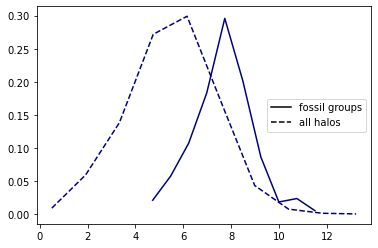

In [74]:
# Compare FGs to non-FGs
fig = None
ax = None
handles = []
linestyles = iter(['-', '--'])
cat_names = iter(["fossil groups", "all halos"])
for this_category in [binned_fgs, target_idx]:
    current_linestyle = next(linestyles)
    current_label = next(cat_names)
    cdeltas, fig, ax = help_func_haccytrees.plot_cdeltas(forest, this_category, fig, ax, linestyle = current_linestyle)
    ax.legend()
    fake_line, = ax.plot([],[], linestyle = current_linestyle, color = 'black', label = current_label)
    handles.append(fake_line)
    
ax.legend(handles = handles, loc = "center right")

#fig.savefig("cdelta_comp_4bins.png")

In [75]:
cdeltas = forest['sod_halo_cdelta'][fgs]
mean = np.average(cdeltas)
high_c_mask = cdeltas >= mean
low_c_mask = cdeltas < mean
high_c_fgs = fgs[high_c_mask]
low_c_fgs = fgs[low_c_mask]
print(len(high_c_fgs))
print(len(low_c_fgs))

193
189


In [76]:
# Find EV fractions for high c's
x_coords = forest['fof_halo_center_x'][high_c_fgs].astype(int) # this just rounds everything down. Is that what we want?
y_coords = forest['fof_halo_center_y'][high_c_fgs].astype(int) # How different would it be if we rounded up?
z_coords = forest['fof_halo_center_z'][high_c_fgs].astype(int)
general_sigs = smooth_sigs[x_coords, y_coords, z_coords]
general_sig_keys, general_sig_counts = np.unique(general_sigs, return_counts=True)
general_vol_fractions = general_sig_counts / np.sum(general_sig_counts)
print(general_sig_counts)
print(general_vol_fractions)

[  9 111  70   3]
[0.04663212 0.57512953 0.3626943  0.01554404]


In [77]:
# Find EV fractions for low c's
x_coords = forest['fof_halo_center_x'][low_c_fgs].astype(int) # this just rounds everything down. Is that what we want?
y_coords = forest['fof_halo_center_y'][low_c_fgs].astype(int) # How different would it be if we rounded up?
z_coords = forest['fof_halo_center_z'][low_c_fgs].astype(int)
general_sigs = smooth_sigs[x_coords, y_coords, z_coords]
general_sig_keys, general_sig_counts = np.unique(general_sigs, return_counts=True)
general_vol_fractions = general_sig_counts / np.sum(general_sig_counts)
print(general_sig_counts)
print(general_vol_fractions)

[21 96 66  6]
[0.11111111 0.50793651 0.34920635 0.03174603]


# Look at surrounding EV

- Can I find out the virial radius and test within that range?
- Also, should I test in a circle, or a rectangle?

In [69]:
# Find the cells immediately surrounding halo centers (within a radius of 1Mpc/h)
radius = np.sqrt(2) # Mpc/h
x_centers = x_coords_fg # Note, these are not integers (so you have to change them when you try to find signatures)
y_centers = y_coords_fg
z_centers = z_coords_fg

10


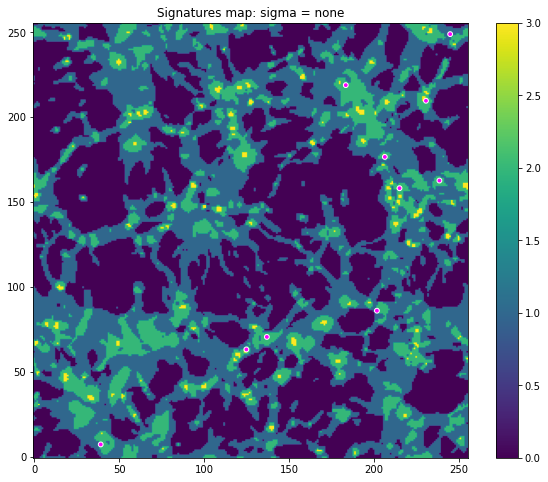

In [70]:
# Visualize circles
slice_n = 174
mask = np.abs(z_centers - slice_n) < 4
print(len(mask[mask]))
these_x_centers = x_centers[mask]
these_y_centers = y_centers[mask]
fig, ax = plt.subplots(figsize=(10, 8))
pcm = ax.imshow(smooth_sigs[:, :, slice_n].T, cmap='viridis', vmin=0, vmax=3, origin = 'lower')
for i in range(len(these_x_centers)):
    circle = plt.Circle((these_x_centers[i], these_y_centers[i]), radius, fill = True, ec="white", fc ="fuchsia")
    ax.add_patch(circle)
fig.colorbar(pcm)

if signatures_are_of_smooth_field:
    ax.set_title("Signatures map: sigma = " + str(sigma))
    fig.savefig("circles-int.png")
else:
    ax.set_title("Signatures map (unsmoothed field)")
    fig.savefig("circles-int.png")

In [71]:
#%%time
# Find environments within circles
axis = np.linspace(0, L, N, endpoint = True)#.astype(int)
x, y, z = np.meshgrid(axis, axis, axis, indexing='ij')

# Find all cells that are within the sphere drawn by that radius
masks = []
argwheres = [] # args where cells fall within the radius
center_signatures = []
signatures = []
for i in range(len(fgs)): # another way to write this? More generally?
    this_center_signature = smooth_sigs[x_centers[i].astype(int), y_centers[i].astype(int), z_centers[i].astype(int)] # sig of the FG itself
    center_signatures.append(this_center_signature)
    this_mask = (x-x_centers[i])**2 + (y-y_centers[i])**2 + (z-z_centers[i])**2 <= radius**2
    argwheres.append(np.argwhere(this_mask == True))
    masks.append(this_mask)
    signatures.append(smooth_sigs[this_mask])

#center_sig_keys, center_sig_counts = np.unique(center_signatures, return_counts=True)
#fg_vol_fractions = fg_sig_counts / np.sum(fg_sig_counts)

In [72]:
print(argwheres[0][0][0:2])

[20 33]


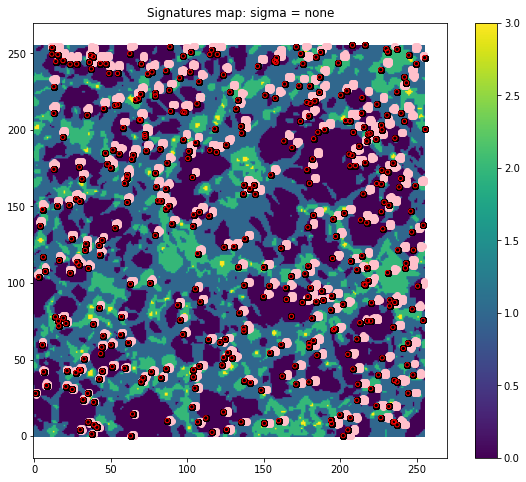

In [73]:
# Visualize circles (another way!)
fig, ax = plt.subplots(figsize=(10, 8))
slice_n = 100
pcm = ax.imshow(smooth_sigs[:, :, slice_n].T, cmap='viridis', vmin=0, vmax=3, origin = 'lower')
fig.colorbar(pcm)

for i, these_argwheres in enumerate(argwheres):
    #print(these_argwheres[:, 0])
    #print(these_argwheres[:][0], these_argwheres[:][2])
    ax.scatter(these_argwheres[:, 0], these_argwheres[:, 1], c = "pink") # only x and y coords # Why is the point size so big (and I can't seem to change it?)
    ax.scatter(x_centers, y_centers, c = "black")
    circle = plt.Circle((x_centers[i], y_centers[i]), radius, fill = False, ec="red")
    ax.add_patch(circle) 

if signatures_are_of_smooth_field:
    ax.set_title("Signatures map: sigma = " + str(sigma))
    #fig.savefig("circles-int.png")
else:
    ax.set_title("Signatures map (unsmoothed field)")
    #fig.savefig("circles-int.png")

In [16]:
print(x_centers[0])
print(y_centers[0])
print(z_centers[0])
#print(axis)

20.253141
31.52399
56.060314


#### What's the problem?
- not sure if I'm `int`ing the center coordinates too soon? (since I'm not `int`ing the other coordinates at all anymore)
- signatures doesn't seem to be including the location (and therefore value) of the center itself? Anywhere?
- even when I leave the center coordinates un-`int`ed (`int`-ing rounds them down, btw) they still don't get included
- maybe I need to see exactly what coordinates it is finding as solutions

In [23]:
print(x_centers[2])
print(y_centers[2])
print(z_centers[2])
this_mask = (x-x_centers[2])**2 + (y-y_centers[2])**2 + (z-z_centers[2])**2 <= radius**2
print(np.argwhere(this_mask == True)) # if these are the args, are the actual values perhaps different?
#(26-x_centers[2])**2 + (40-y_centers[2])**2 + (59-z_centers[2])**2 <= radius**2
print("x: ", x[27])
print("y: ", y[0, 41])
print("z: ", z[0, 0, 61])

26.622
40.435047
59.763294
[[26 41 61]
 [26 42 61]
 [27 40 61]
 [27 41 60]
 [27 41 61]
 [27 41 62]
 [27 42 60]
 [27 42 61]
 [27 42 62]
 [28 41 60]
 [28 41 61]
 [28 41 62]
 [28 42 61]]
x:  [[26.47058824 26.47058824 26.47058824 ... 26.47058824 26.47058824
  26.47058824]
 [26.47058824 26.47058824 26.47058824 ... 26.47058824 26.47058824
  26.47058824]
 [26.47058824 26.47058824 26.47058824 ... 26.47058824 26.47058824
  26.47058824]
 ...
 [26.47058824 26.47058824 26.47058824 ... 26.47058824 26.47058824
  26.47058824]
 [26.47058824 26.47058824 26.47058824 ... 26.47058824 26.47058824
  26.47058824]
 [26.47058824 26.47058824 26.47058824 ... 26.47058824 26.47058824
  26.47058824]]
y:  [40.19607843 40.19607843 40.19607843 40.19607843 40.19607843 40.19607843
 40.19607843 40.19607843 40.19607843 40.19607843 40.19607843 40.19607843
 40.19607843 40.19607843 40.19607843 40.19607843 40.19607843 40.19607843
 40.19607843 40.19607843 40.19607843 40.19607843 40.19607843 40.19607843
 40.19607843 40.19607843

In [56]:
for i in range(len(signatures)):
    print(center_signatures[i], ": ", signatures[i])

3 :  [3 2 3 3 2 2 2]
3 :  [2 3 3 3 2 2 3]
2 :  [3 3 3 3 3 3 3]
2 :  [2 2 2 2 2 2 2 2 2 2 2]
2 :  [3 3 2 2 2 2 2]
2 :  [2 2 2 2 2 2 2]
2 :  [2 2 2 2 2 2 2]
2 :  [3 3 2 3 3 2 2]
2 :  [3 3 3 3 2 2 2]
1 :  [3 2 2 2 2 2 1]
2 :  [3 3 3 3 3 3 3]
2 :  [3 3 3 3 2 2 2]
2 :  [2 2 2 2 2 2 2]
1 :  [2 3 3 3 2 2 3]
1 :  [2 3 2 2 2 2 3]
2 :  [2 3 3 2 3 3 2 3]
2 :  [2 2 2 2 2 2 2 2]
1 :  [3 2 2 3 3 2 2]
1 :  [3 2 2 3 2 2 2]
2 :  [2 3 2 3 3 2 2]
1 :  [2 2 2 3 3 3 3]
2 :  [3 2 2 3 3 3 3]
0 :  [2 2 2 2 2 2 2 2]
1 :  [3 3 2 3 3 2 2]
1 :  [2 2 2 2 2 2 2 2 2 2 2]
2 :  [3 3 3 3 3 3 3]
2 :  [2 3 2 3 3 2 3]
1 :  [3 3 3 3 3 3 2 3]
2 :  [3 3 3 3 2 2 2 2]
1 :  [3 2 3 3 2 2 2]
2 :  [3 3 3 3 2 2 2]
2 :  [2 2 2 2 2 2 2]
3 :  [2 2 2 2 2 2 2]
2 :  [3 3 3 3 3 3 2]
1 :  [2 2 2 3 2 2 3]
1 :  [3 2 3 3 2 3 2]
1 :  [3 3 3 3 3 3 2]
1 :  [3 3 3 3 2 3 2]
1 :  [3 3 3 3 3 2 3]
2 :  [3 3 2 2 3 3 2 2]
2 :  [2 2 2 2 2 2 2]
2 :  [3 2 3 3 3 2 2]
2 :  [3 3 3 3 3 3 3]
2 :  [2 2 2 2 2 2 2]
0 :  [3 3 2 3 3 2 2]
2 :  [2 2 2 2 2 2 2]
2 :  [